# Optical Neural Network for MNIST Classification

Reproduction of the diffractive deep neural network (D$^2$NN) from [Lin et al., Science 2018](https://www.science.org/doi/10.1126/science.aat8084) and [Yan et al., IEEE 2019](https://ieeexplore.ieee.org/abstract/document/8732486).

A 5-layer phase-only optical network is trained to classify MNIST digits using MSE loss.

In [1]:
import random
import time

import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import InterpolationMode
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as patches

plt.style.use('dark_background')
%matplotlib inline

In [2]:
from svetlanna import SimulationParameters, ConstrainedParameter
from svetlanna import elements
from svetlanna.setup import LinearOpticalSetup
from svetlanna.detector import Detector, DetectorProcessorClf
from svetlanna.transforms import ToWavefront

if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'

print(f'Using device: {DEVICE}')

Using device: cuda


# 1. Simulation Parameters

In [3]:
# Physical constants
working_frequency = 0.4e12  # [Hz]
c_const = 299_792_458  # [m/s]
working_wavelength = c_const / working_frequency  # [m]

# Neuron (pixel) size — 0.53 lambda
neuron_size = 0.53 * working_wavelength  # [m]

print(f'Wavelength: {working_wavelength * 1e6:.1f} um')
print(f'Neuron size: {neuron_size * 1e6:.1f} um')

Wavelength: 749.5 um
Neuron size: 397.2 um


In [4]:
# Layer / detector dimensions (200 x 200 neurons)
DETECTOR_SIZE = (200, 200)
x_layer_nodes = DETECTOR_SIZE[1]
y_layer_nodes = DETECTOR_SIZE[0]

x_layer_size_m = x_layer_nodes * neuron_size  # [m]
y_layer_size_m = y_layer_nodes * neuron_size  # [m]

print(f'Layer: {x_layer_nodes}x{y_layer_nodes} neurons, '
      f'{x_layer_size_m*1e2:.2f}x{y_layer_size_m*1e2:.2f} cm')

Layer: 200x200 neurons, 7.94x7.94 cm


In [5]:
SIM_PARAMS = SimulationParameters(
    x=torch.linspace(-x_layer_size_m / 2, x_layer_size_m / 2, x_layer_nodes),
    y=torch.linspace(-y_layer_size_m / 2, y_layer_size_m / 2, y_layer_nodes),
    wavelength=working_wavelength,
)
print(SIM_PARAMS)

SimulationParameters(wavelength=0.000749, x=(200,), y=(200,))


# 2. Dataset

## 2.1. Load MNIST

In [6]:
MNIST_DATA_FOLDER = './data'

mnist_train_ds = torchvision.datasets.MNIST(
    root=MNIST_DATA_FOLDER, train=True, download=True,
)
mnist_test_ds = torchvision.datasets.MNIST(
    root=MNIST_DATA_FOLDER, train=False, download=True,
)

print(f'Train: {len(mnist_train_ds)}, Test: {len(mnist_test_ds)}')

Train: 60000, Test: 10000


## 2.2. Detector Mask

10 square zones (one per digit class) arranged in a grid on the detector plane.
Each zone is $6.4\lambda \times 6.4\lambda$.

In [7]:
NUM_CLASSES = 10

# Zone size in neurons
detector_segment_size = 6.4 * working_wavelength  # [m]
seg = int(detector_segment_size / neuron_size)  # ~12 neurons

# Create detector mask: 10 squares in a 4-row x 3-column grid
# (last row has 1 centered zone for digit 9)
n_cols_grid = 3
n_rows_grid = 4  # ceil(10 / 3)

boundary_y = seg * 9  # active area height
boundary_x = seg * 9  # active area width

# Cell sizes within the grid
cell_y = boundary_y // n_rows_grid  # pixels per row cell
cell_x = boundary_x // n_cols_grid  # pixels per col cell

DETECTOR_MASK = -torch.ones(boundary_y, boundary_x, dtype=torch.int32)

for cls in range(NUM_CLASSES):
    row, col = divmod(cls, n_cols_grid)
    # Center the square within its cell
    y0 = row * cell_y + (cell_y - seg) // 2
    if row == n_rows_grid - 1:  # last row: center the remaining zones
        n_last = NUM_CLASSES - row * n_cols_grid
        total_w = n_last * cell_x
        x_offset = (boundary_x - total_w) // 2
        x0 = x_offset + col * cell_x + (cell_x - seg) // 2
    else:
        x0 = col * cell_x + (cell_x - seg) // 2
    DETECTOR_MASK[y0:y0 + seg, x0:x0 + seg] = cls

# Pad to full simulation grid (center the active area)
sim_y, sim_x = SIM_PARAMS.axis_sizes(('y', 'x'))
pad_top = (sim_y - boundary_y) // 2
pad_bottom = sim_y - pad_top - boundary_y
pad_left = (sim_x - boundary_x) // 2
pad_right = sim_x - pad_left - boundary_x
DETECTOR_MASK = torch.nn.functional.pad(
    DETECTOR_MASK, (pad_left, pad_right, pad_top, pad_bottom), value=-1
)
print(f'Detector mask shape: {DETECTOR_MASK.shape}, zone size: {seg}x{seg} neurons')

Detector mask shape: torch.Size([200, 200]), zone size: 12x12 neurons


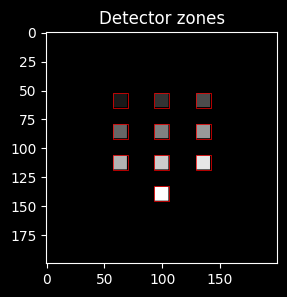

In [8]:
# Visualize detector zones
def get_zones_patches(detector_mask, n_classes=NUM_CLASSES, color='r', lw=0.5):
    """Return matplotlib Rectangle patches for each class zone."""
    zone_patches = []
    for cls in range(n_classes):
        idx_y, idx_x = (detector_mask == cls).nonzero(as_tuple=True)
        rect = patches.Rectangle(
            (idx_x[0] - 1, idx_y[0] - 1),
            idx_x[-1] - idx_x[0] + 2, idx_y[-1] - idx_y[0] + 2,
            linewidth=lw, edgecolor=color, facecolor='none'
        )
        zone_patches.append(rect)
    return zone_patches

fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.set_title('Detector zones')
ax.imshow(DETECTOR_MASK, cmap='grey')
for p in get_zones_patches(DETECTOR_MASK):
    ax.add_patch(p)
plt.show()

## 2.3. Wavefront Dataset

In [36]:
# Image transforms: resize -> pad -> convert to wavefront (amplitude modulation)
resize_y = DETECTOR_SIZE[0] // 3
resize_x = DETECTOR_SIZE[1] // 3

pad_top = (y_layer_nodes - resize_y) // 2
pad_bottom = y_layer_nodes - pad_top - resize_y
pad_left = (x_layer_nodes - resize_x) // 2
pad_right = x_layer_nodes - pad_left - resize_x

image_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((resize_y, resize_x), interpolation=InterpolationMode.NEAREST),
    transforms.Pad((pad_left, pad_top, pad_right, pad_bottom), fill=0),
    ToWavefront(modulation_type='amp'),
])

In [37]:
class MNISTWavefrontDataset(Dataset):
    """MNIST dataset that returns (wavefront, target_detector_image, label)."""

    def __init__(self, mnist_ds, transform, detector_mask):
        self.mnist_ds = mnist_ds
        self.transform = transform
        self.detector_mask = detector_mask

    def __len__(self):
        return len(self.mnist_ds)

    def __getitem__(self, idx):
        image, label = self.mnist_ds[idx]
        wavefront = self.transform(image)
        target = torch.where(self.detector_mask == label, 1.0, 0.0)
        return wavefront, target, label

In [38]:
mnist_wf_train_ds = MNISTWavefrontDataset(mnist_train_ds, image_transform, DETECTOR_MASK)
mnist_wf_test_ds = MNISTWavefrontDataset(mnist_test_ds, image_transform, DETECTOR_MASK)

# Split train into train/val (55000 / 5000) as in the paper
train_wf_ds, val_wf_ds = torch.utils.data.random_split(
    mnist_wf_train_ds,
    [55000, 5000],
    generator=torch.Generator().manual_seed(178),
)

print(f'Train: {len(train_wf_ds)}, Val: {len(val_wf_ds)}, Test: {len(mnist_wf_test_ds)}')

Train: 55000, Val: 5000, Test: 10000


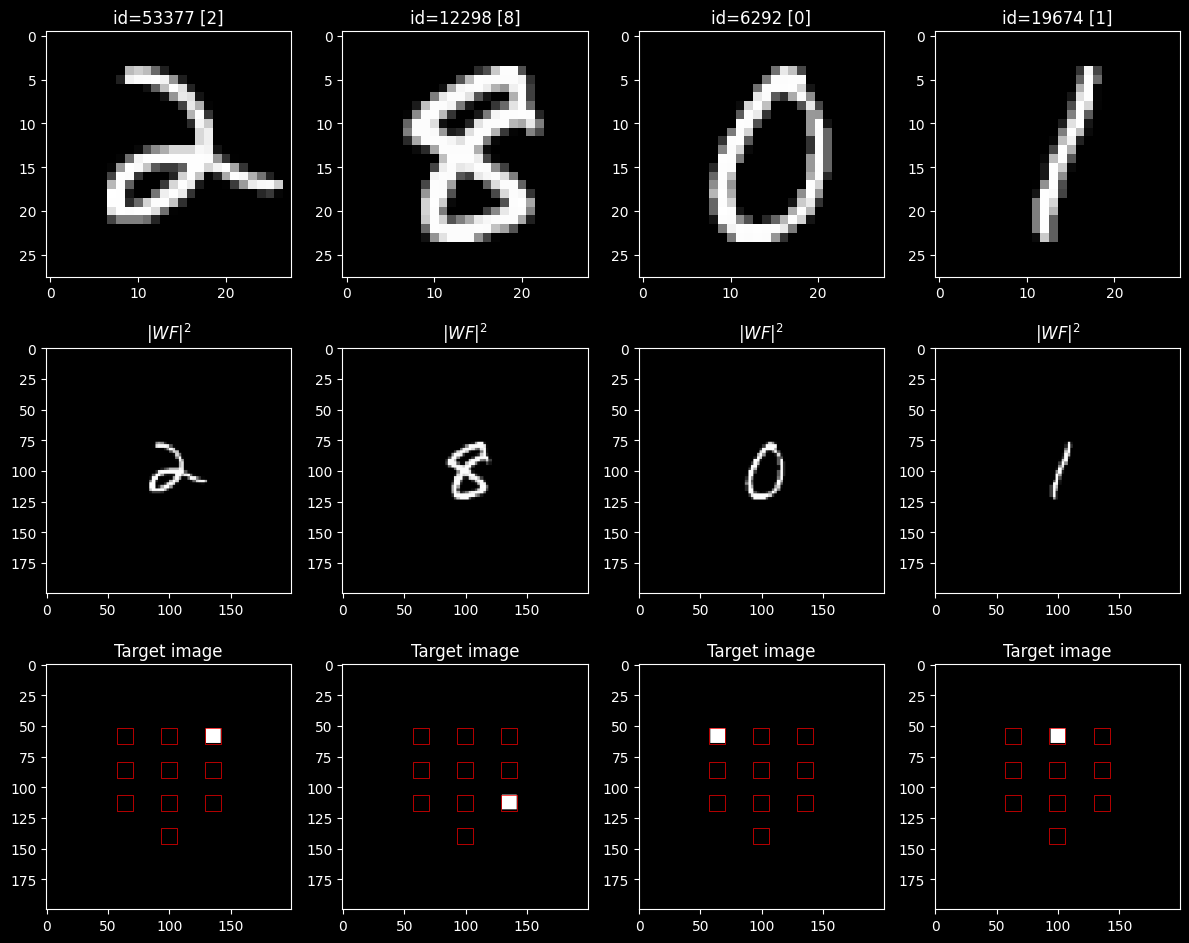

In [39]:
# Visualize examples
random.seed(78)
n_examples = 4
example_ids = random.sample(range(len(mnist_train_ds)), n_examples)

fig, axs = plt.subplots(3, n_examples, figsize=(n_examples * 3, 3 * 3.2))

for i, idx in enumerate(example_ids):
    image, label = mnist_train_ds[idx]
    wavefront, target, _ = mnist_wf_train_ds[idx]

    axs[0][i].set_title(f'id={idx} [{label}]')
    axs[0][i].imshow(image, cmap='gray')

    axs[1][i].set_title(r'$|WF|^2$')
    axs[1][i].imshow(wavefront.intensity, cmap='gray', vmin=0, vmax=1)

    axs[2][i].set_title('Target image')
    axs[2][i].imshow(target, cmap='gray', vmin=0, vmax=1)
    for p in get_zones_patches(DETECTOR_MASK):
        axs[2][i].add_patch(p)

plt.tight_layout()
plt.show()

# 3. Optical Network

## 3.1. Architecture

5 diffractive phase-only layers with free-space propagation between them.
Phase masks are initialized to $\pi$ and constrained to $[0, 2\pi]$ via sigmoid.

In [40]:
NUM_DIFF_LAYERS = 5
FREE_SPACE_DISTANCE = 40 * working_wavelength  # [m]
MAX_PHASE = 2 * np.pi
INIT_PHASE = np.pi
FREESPACE_METHOD = 'AS'

print(f'Distance between layers: {FREE_SPACE_DISTANCE * 1e2:.3f} cm')

Distance between layers: 2.998 cm


In [41]:
def build_elements(sim_params):
    """Build the list of optical elements for the D2NN."""
    y_nodes, x_nodes = sim_params.axis_sizes(('y', 'x'))
    elems = []

    # Initial free-space propagation
    elems.append(elements.FreeSpace(
        simulation_parameters=sim_params,
        distance=FREE_SPACE_DISTANCE,
        method=FREESPACE_METHOD,
    ))

    for _ in range(NUM_DIFF_LAYERS):
        # Diffractive layer (learnable phase mask)
        mask = torch.ones(y_nodes, x_nodes) * INIT_PHASE
        elems.append(elements.DiffractiveLayer(
            simulation_parameters=sim_params,
            mask=ConstrainedParameter(mask, min_value=0, max_value=MAX_PHASE),
        ))
        # Free-space propagation
        elems.append(elements.FreeSpace(
            simulation_parameters=sim_params,
            distance=FREE_SPACE_DISTANCE,
            method=FREESPACE_METHOD,
        ))

    # Detector
    elems.append(Detector(simulation_parameters=sim_params, func='intensity'))
    return elems

optical_setup = LinearOpticalSetup(elements=build_elements(SIM_PARAMS))
print(f'Elements in setup: {len(optical_setup.net)}')

Elements in setup: 12


In [42]:
detector_processor = DetectorProcessorClf(
    num_classes=NUM_CLASSES,
    simulation_parameters=SIM_PARAMS,
    segmented_detector=DETECTOR_MASK,
    device=DEVICE,
)
optical_setup.net

Sequential(
  (0): FreeSpace(
    (simulation_parameters): SimulationParameters(wavelength=0.000749, x=(200,), y=(200,))
  )
  (1): DiffractiveLayer(
    (simulation_parameters): SimulationParameters(wavelength=0.000749, x=(200,), y=(200,))
    (mask_svtlnn_inner_parameter): InnerParameterStorageModule()
  )
  (2): FreeSpace(
    (simulation_parameters): SimulationParameters(wavelength=0.000749, x=(200,), y=(200,))
  )
  (3): DiffractiveLayer(
    (simulation_parameters): SimulationParameters(wavelength=0.000749, x=(200,), y=(200,))
    (mask_svtlnn_inner_parameter): InnerParameterStorageModule()
  )
  (4): FreeSpace(
    (simulation_parameters): SimulationParameters(wavelength=0.000749, x=(200,), y=(200,))
  )
  (5): DiffractiveLayer(
    (simulation_parameters): SimulationParameters(wavelength=0.000749, x=(200,), y=(200,))
    (mask_svtlnn_inner_parameter): InnerParameterStorageModule()
  )
  (6): FreeSpace(
    (simulation_parameters): SimulationParameters(wavelength=0.000749, x=(20

## 3.2. Example Propagation (before training)

In [ ]:
example_wf = mnist_wf_train_ds[128][0].to(DEVICE)
scheme, wavefronts = optical_setup.stepwise_forward(example_wf)
print(scheme)

n_cols = 5
n_rows = len(wavefronts) // n_cols + 1

fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3.2))
for r in range(n_rows):
    for c in range(n_cols):
        idx = r * n_cols + c
        if idx >= len(wavefronts):
            axs[r][c].axis('off')
            continue
        wf = wavefronts[idx]
        if idx < len(wavefronts) - 1:
            axs[r][c].set_title(f'Intensity $WF_{{{idx}}}$')
            axs[r][c].imshow(wf.intensity.cpu().detach().numpy(), cmap='grey')
        else:
            axs[r][c].set_title('Detector')
            axs[r][c].imshow(wf.cpu().detach().numpy(), cmap='hot')
plt.tight_layout()
plt.show()

# 4. Training

## 4.1. Setup

In [54]:
# Hyperparameters
LR = 1e-3
n_epochs = 20
train_bs = 64
val_bs = 128
print_each = 2  # print info every N epochs

In [55]:
train_loader = DataLoader(train_wf_ds, batch_size=train_bs, shuffle=True, drop_last=False, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_wf_ds, batch_size=val_bs, shuffle=False, drop_last=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(mnist_wf_test_ds, batch_size=val_bs, shuffle=False, drop_last=False, num_workers=4, pin_memory=True)

In [56]:
# Recreate setup for a fresh start
optical_setup = LinearOpticalSetup(elements=build_elements(SIM_PARAMS))
optical_setup.net.to(DEVICE)
optimizer = torch.optim.Adam(optical_setup.net.parameters(), lr=LR)
loss_fn = nn.MSELoss()

## 4.2. Training Loop

In [57]:
train_losses_hist = []
val_losses_hist = []
train_acc_hist = []
val_acc_hist = []

torch.manual_seed(98)

for epoch in range(n_epochs):
    verbose = (epoch == 0) or ((epoch + 1) % print_each == 0) or (epoch == n_epochs - 1)
    if verbose:
        print(f'Epoch {epoch + 1}/{n_epochs}')

    # --- Train ---
    optical_setup.net.train()
    batch_losses = []
    correct, total = 0, 0
    t0 = time.time()

    for batch_wf, batch_target, batch_label in tqdm(
        train_loader, desc='train', disable=not verbose, leave=True
    ):
        batch_wf = batch_wf.to(DEVICE)
        batch_target = batch_target.to(DEVICE)
        batch_label = batch_label.to(DEVICE)

        optimizer.zero_grad()
        detector_out = optical_setup.net(batch_wf)
        loss = loss_fn(detector_out, batch_target)
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

        # Accuracy
        with torch.no_grad():
            preds = detector_processor.batch_forward(detector_out).argmax(1)
            correct += (preds == batch_label).sum().item()
            total += batch_label.size(0)

    train_loss = np.mean(batch_losses)
    train_acc = correct / total
    train_losses_hist.append(train_loss)
    train_acc_hist.append(train_acc)

    if verbose:
        print(f'  Train — MSE: {train_loss:.6f}, Acc: {train_acc*100:.1f}% ({time.time()-t0:.1f}s)')

    # --- Validation ---
    optical_setup.net.eval()
    batch_losses = []
    correct, total = 0, 0
    t0 = time.time()

    for batch_wf, batch_target, batch_label in tqdm(
        val_loader, desc='val', disable=not verbose, leave=True
    ):
        batch_wf = batch_wf.to(DEVICE)
        batch_target = batch_target.to(DEVICE)
        batch_label = batch_label.to(DEVICE)

        with torch.no_grad():
            detector_out = optical_setup.net(batch_wf)
            loss = loss_fn(detector_out, batch_target)

        batch_losses.append(loss.item())

        preds = detector_processor.batch_forward(detector_out).argmax(1)
        correct += (preds == batch_label).sum().item()
        total += batch_label.size(0)

    val_loss = np.mean(batch_losses)
    val_acc = correct / total
    val_losses_hist.append(val_loss)
    val_acc_hist.append(val_acc)

    if verbose:
        print(f'  Val   — MSE: {val_loss:.6f}, Acc: {val_acc*100:.1f}% ({time.time()-t0:.1f}s)')

Epoch 1/20


train: 100%|██████████| 860/860 [01:21<00:00, 10.50it/s]


  Train — MSE: 0.003483, Acc: 39.6% (81.9s)


val: 100%|██████████| 40/40 [00:08<00:00,  4.80it/s]


  Val   — MSE: 0.002830, Acc: 69.5% (8.3s)
Epoch 2/20


...

Epoch 20/20


train: 100%|██████████| 860/860 [01:18<00:00, 11.02it/s]


  Train — MSE: 0.001843, Acc: 82.4% (78.1s)


val: 100%|██████████| 40/40 [00:07<00:00,  5.15it/s]

  Val   — MSE: 0.001848, Acc: 81.5% (7.8s)


## 4.3. Results

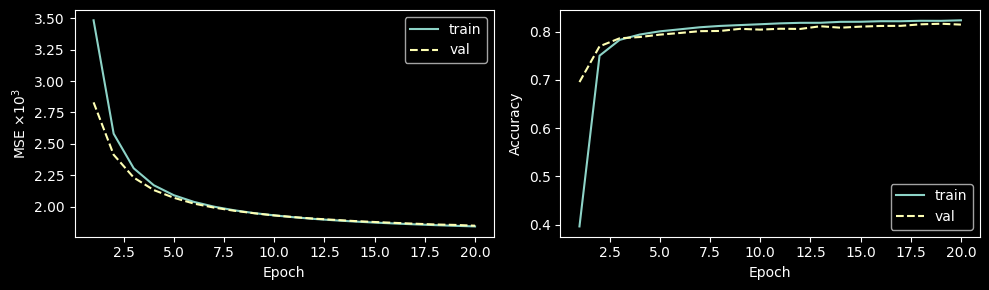

In [58]:
# Learning curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

epochs_range = range(1, n_epochs + 1)

ax1.plot(epochs_range, np.array(train_losses_hist) * 1e3, label='train')
ax1.plot(epochs_range, np.array(val_losses_hist) * 1e3, '--', label='val')
ax1.set_xlabel('Epoch')
ax1.set_ylabel(r'MSE $\times 10^3$')
ax1.legend()

ax2.plot(epochs_range, train_acc_hist, label='train')
ax2.plot(epochs_range, val_acc_hist, '--', label='val')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

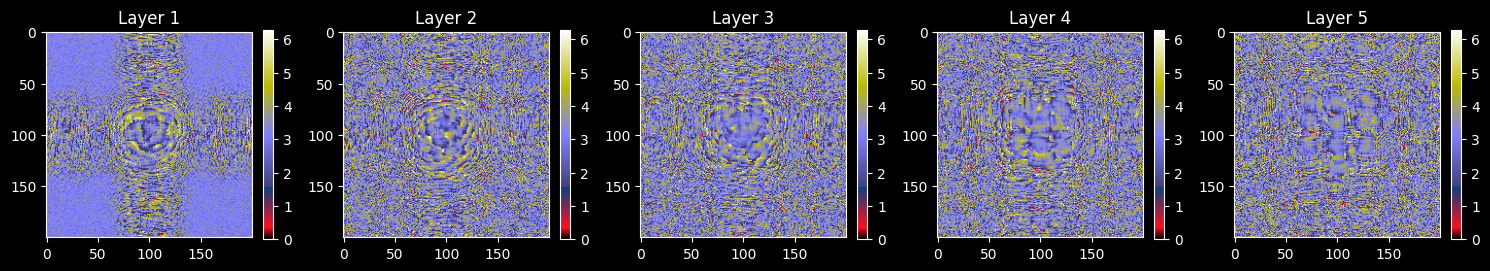

In [59]:
# Visualize trained phase masks
diff_layers = [
    layer for layer in optical_setup.net if isinstance(layer, elements.DiffractiveLayer)
]

fig, axs = plt.subplots(1, len(diff_layers), figsize=(len(diff_layers) * 3, 3.2))
for i, layer in enumerate(diff_layers):
    mask = layer.mask.cpu().detach().numpy()
    axs[i].set_title(f'Layer {i + 1}')
    im = axs[i].imshow(mask, cmap='gist_stern', vmin=0, vmax=MAX_PHASE)
    plt.colorbar(im, ax=axs[i], fraction=0.046)
plt.tight_layout()
plt.show()

# 5. Evaluation

In [60]:
# Test set accuracy
optical_setup.net.eval()
correct, total = 0, 0
test_losses = []

for batch_wf, batch_target, batch_label in tqdm(test_loader, desc='test'):
    batch_wf = batch_wf.to(DEVICE)
    batch_target = batch_target.to(DEVICE)
    batch_label = batch_label.to(DEVICE)

    with torch.no_grad():
        detector_out = optical_setup.net(batch_wf)
        loss = loss_fn(detector_out, batch_target)

    test_losses.append(loss.item())
    preds = detector_processor.batch_forward(detector_out).argmax(1)
    correct += (preds == batch_label).sum().item()
    total += batch_label.size(0)

print(f'Test MSE: {np.mean(test_losses):.6f}')
print(f'Test Accuracy: {correct / total * 100:.1f}%')

test: 100%|██████████| 79/79 [00:15<00:00,  5.00it/s]

Test MSE: 0.001804
Test Accuracy: 83.0%


## 5.1. Example Classification

-(0)-> [1. FreeSpace] -(1)-> [2. DiffractiveLayer] -(2)-> [3. FreeSpace] -(3)-> [4. DiffractiveLayer] -(4)-> [5. FreeSpace] -(5)-> [6. DiffractiveLayer] -(6)-> [7. FreeSpace] -(7)-> [8. DiffractiveLayer] -(8)-> [9. FreeSpace] -(9)-> [10. DiffractiveLayer] -(10)-> [11. FreeSpace] -(11)-> [12. Detector] -(12)->


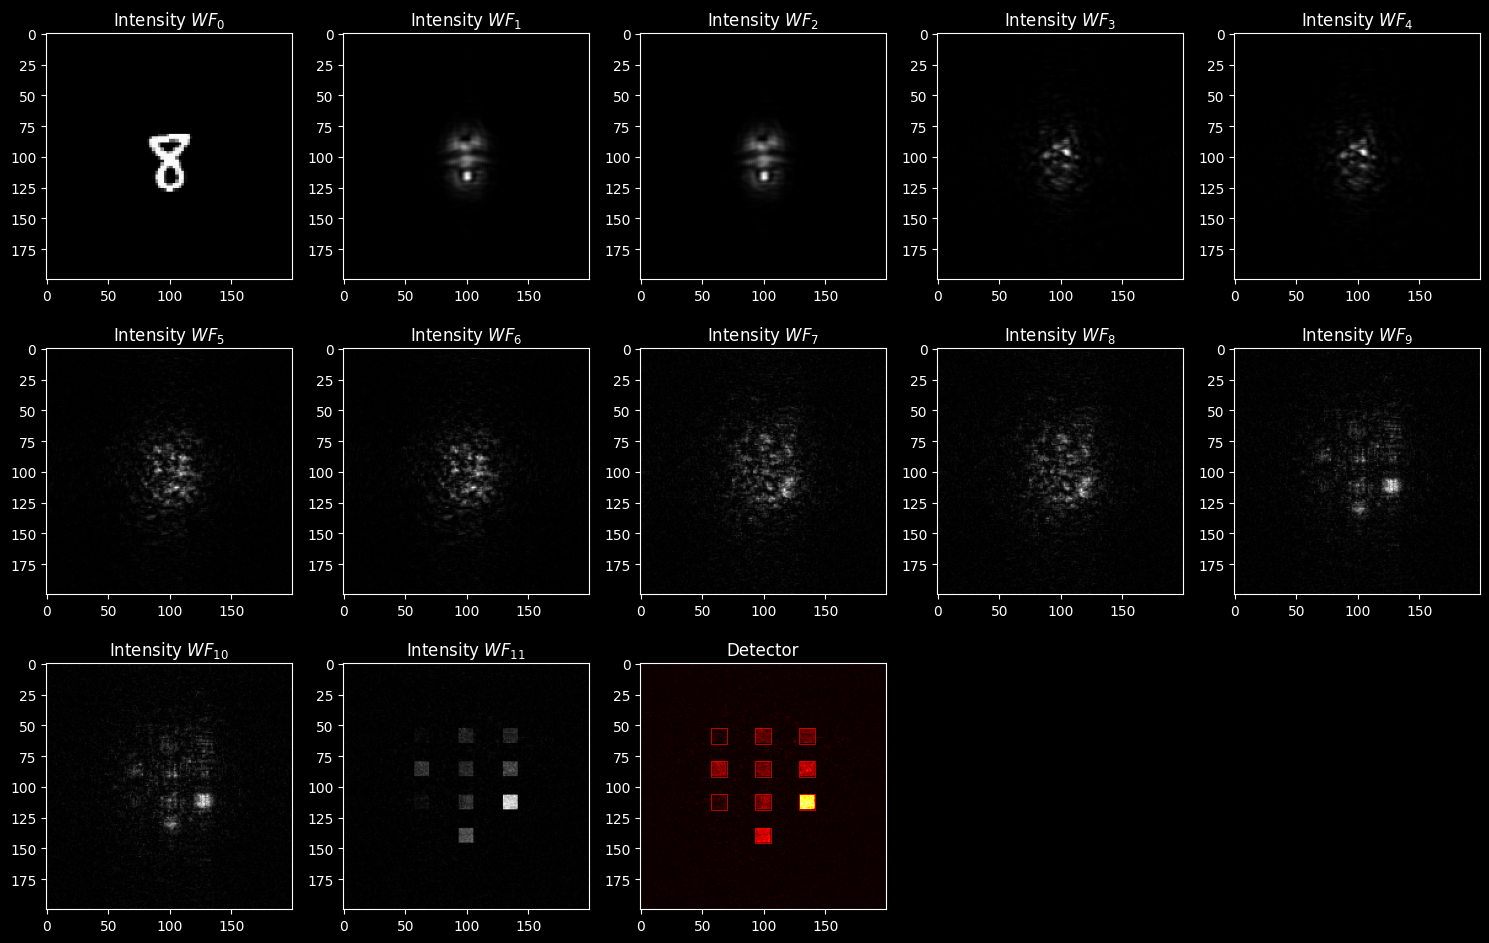


True label: 8
  0: 1.33%
  1: 5.60%
  2: 6.08%
  3: 8.63%
  4: 6.69%
  5: 11.73%
  6: 2.05%
  7: 7.88%
  8: 36.23% <--
  9: 13.79%


In [63]:
# Propagate a single test sample through the trained network
ind_test = 128
test_wf, test_target, test_label = mnist_wf_test_ds[ind_test]
test_wf = test_wf.to(DEVICE)

scheme, test_wavefronts = optical_setup.stepwise_forward(test_wf)
print(scheme)

n_cols = 5
n_rows = len(test_wavefronts) // n_cols + 1

fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3.2))
for r in range(n_rows):
    for c in range(n_cols):
        idx = r * n_cols + c
        if idx >= len(test_wavefronts):
            axs[r][c].axis('off')
            continue
        wf = test_wavefronts[idx]
        if idx < len(test_wavefronts) - 1:
            axs[r][c].set_title(f'Intensity $WF_{{{idx}}}$')
            axs[r][c].imshow(wf.intensity.cpu().detach().numpy(), cmap='grey')
        else:
            axs[r][c].set_title('Detector')
            axs[r][c].imshow(wf.cpu().detach().numpy(), cmap='hot')
            for p in get_zones_patches(DETECTOR_MASK):
                axs[r][c].add_patch(p)
plt.tight_layout()
plt.show()

# Class probabilities
probas = detector_processor.batch_forward(test_wavefronts[-1].unsqueeze(0))
print(f'\nTrue label: {test_label}')
for cls, prob in enumerate(probas[0]):
    marker = ' <--' if cls == probas[0].argmax().item() else ''
    print(f'  {cls}: {prob * 100:.2f}%{marker}')

## 5.2. Save Weights

In [ ]:
# torch.save(optical_setup.net.state_dict(), 'models/mnist_mse_d2nn.pth')
# print('Model saved.')